In [21]:
import torch
import torch.nn as nn
import pandas as pd
from utils.model_utils import validate, train, evaluate, get_tensor_dataset, get_data_loader
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [22]:
train_df = pd.read_csv('data/train.csv')
test_df = pd.read_csv('data/test.csv')
val_df = pd.read_csv('data/val.csv')

In [23]:
label = 'label'
train_dataset = get_tensor_dataset(train_df, label)
test_dataset = get_tensor_dataset(test_df, label)
val_dataset = get_tensor_dataset(val_df, label)

print(train_dataset)
print(test_dataset)
print(val_dataset)

In [24]:
BATCH_SIZE = 32
train_loader = get_data_loader(train_dataset, BATCH_SIZE)
test_loader = get_data_loader(test_dataset, BATCH_SIZE)
val_loader = get_data_loader(val_dataset, BATCH_SIZE)

In [25]:
model = nn.Sequential(
    nn.Linear(1024, 256),
    nn.ReLU(),
    nn.Dropout(0.3),

    nn.Linear(256, 64),
    nn.ReLU(),
    nn.Dropout(0.2),

    nn.Linear(64, 1)
)
model.to(device)
print(model)

Sequential(
  (0): Linear(in_features=1024, out_features=256, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=256, out_features=64, bias=True)
  (4): ReLU()
  (5): Dropout(p=0.2, inplace=False)
  (6): Linear(in_features=64, out_features=1, bias=True)
)


In [26]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
THRESHOLD = 0.5

In [27]:
best_loss = float('inf')
patience = 5
counter = 0

for epoch in range(50):
    print("Epoch:", epoch)
    train(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        optimizer=optimizer,
        train_loader=train_loader,
        device=device
    )
    val_loss = validate(
        model=model,
        loss_function=criterion,
        threshold=THRESHOLD,
        val_loader=val_loader,
        device=device
    )
    print("-" * 40)

    if val_loss < best_loss:
        best_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "../model_repository/pneumonia_model_phase_1.pth")
    else:
        counter += 1
        if counter >= patience:
            print("Early stopping")
            break

Epoch: 0
Train - Loss: 0.2161 Accuracy: 0.9052
Valid - Loss: 0.1142 Accuracy: 0.9591
----------------------------------------
Epoch: 1
Train - Loss: 0.1161 Accuracy: 0.9559
Valid - Loss: 0.0969 Accuracy: 0.9578
----------------------------------------
Epoch: 2
Train - Loss: 0.1050 Accuracy: 0.9595
Valid - Loss: 0.0950 Accuracy: 0.9578
----------------------------------------
Epoch: 3
Train - Loss: 0.0960 Accuracy: 0.9633
Valid - Loss: 0.1245 Accuracy: 0.9527
----------------------------------------
Epoch: 4
Train - Loss: 0.0889 Accuracy: 0.9682
Valid - Loss: 0.0860 Accuracy: 0.9668
----------------------------------------
Epoch: 5
Train - Loss: 0.0826 Accuracy: 0.9718
Valid - Loss: 0.1000 Accuracy: 0.9629
----------------------------------------
Epoch: 6
Train - Loss: 0.0773 Accuracy: 0.9712
Valid - Loss: 0.1124 Accuracy: 0.9552
----------------------------------------
Epoch: 7
Train - Loss: 0.0763 Accuracy: 0.9710
Valid - Loss: 0.0885 Accuracy: 0.9668
---------------------------------

===== EVALUATION METRICS =====
Accuracy  : 0.9630
Precision : 0.9964
Recall    : 0.9536
F1 Score  : 0.9745

Confusion Matrix:
 [[199   2]
 [ 27 555]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.88      0.99      0.93       201
         1.0       1.00      0.95      0.97       582

    accuracy                           0.96       783
   macro avg       0.94      0.97      0.95       783
weighted avg       0.97      0.96      0.96       783



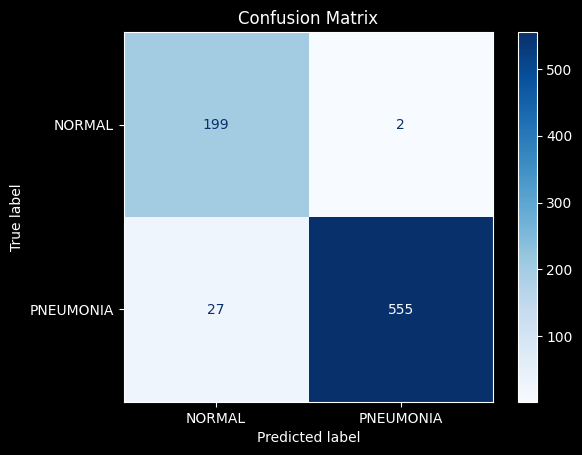

In [28]:
evaluate(model=model,
         threshold=THRESHOLD,
         data_loader=test_loader,
         device=device,
         labels=["NORMAL", "PNEUMONIA"])

In [29]:
from sklearn.metrics import roc_curve

model.load_state_dict(torch.load("../model_repository/pneumonia_model_phase_1.pth"))
model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for X_batch, y_batch in val_loader:
        X_batch = X_batch.to(device)
        logits = model(X_batch).squeeze()
        probs = torch.sigmoid(logits).cpu().numpy()

        all_probs.extend(probs)
        all_labels.extend(y_batch.numpy())

all_probs = np.array(all_probs)
all_labels = np.array(all_labels)

fpr, tpr, roc_thresholds = roc_curve(all_labels, all_probs)
j_scores = tpr - fpr
best_threshold = roc_thresholds[np.argmax(j_scores)]

print("Chosen threshold:", best_threshold)

Chosen threshold: 0.6599028


===== EVALUATION METRICS =====
Accuracy  : 0.9732
Precision : 0.9965
Recall    : 0.9674
F1 Score  : 0.9817

Confusion Matrix:
 [[199   2]
 [ 19 563]]

Detailed Classification Report:

              precision    recall  f1-score   support

         0.0       0.91      0.99      0.95       201
         1.0       1.00      0.97      0.98       582

    accuracy                           0.97       783
   macro avg       0.95      0.98      0.97       783
weighted avg       0.97      0.97      0.97       783



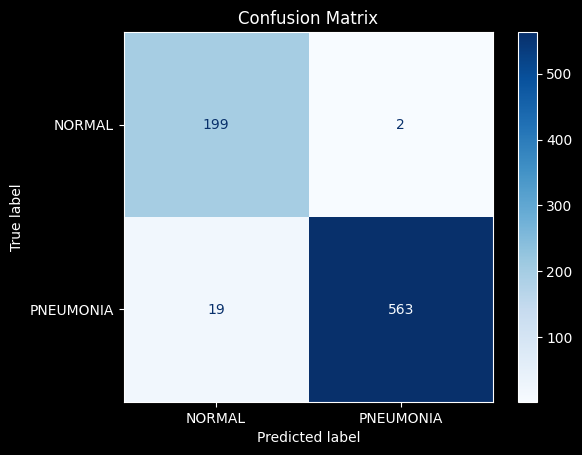

In [30]:
THRESHOLD = best_threshold
evaluate(
    model=model,
    threshold=THRESHOLD,
    data_loader=test_loader,
    device=device,
    labels=["NORMAL", "PNEUMONIA"]
)